# 🧠 Mental Health & Burnout in Tech (2026)
## End-to-End Machine Learning Pipeline

**Dataset:** `mental_health_burnout_tech_2026.csv` — 100,000 tech-worker records, 36 columns, no missing values.

**Goal:** Predict `burnout_level` (Low / Moderate / High / Severe) from workplace, lifestyle, and self-reported wellbeing features — without using direct burnout/PHQ-9/GAD-7 scores as inputs (those leak the target).

### Workflow
| Step | Description |
| ---- | ----------- |
| 1 | Load & inspect |
| 2 | Missing values + drop duplicates |
| 3 | Univariate analysis & visualisations |
| 4 | Outlier detection (IQR multi-column rule) |
| 5 | Feature engineering (19 derived features) |
| 6 | Preprocessing & stratified train/test split |
| 7 | Train: Logistic Regression · HGB · XGBoost · Soft-Voting Ensemble |
| 8 | Evaluate: confusion matrix · per-class F1 · permutation importance |
| 9 | Save artefacts for the Streamlit dashboard |

## 1 · Imports & Display Settings

In [1]:
%matplotlib inline
import json, time, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder,
                                    StandardScaler, TargetEncoder)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from feature_engineering import MODEL_CATEGORICAL_COLS, RAW_CATEGORICAL_COLS, engineer_features

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 4)})
print('All imports OK ✓')

All imports OK ✓


## 2 · Configuration

In [2]:
HERE      = Path().resolve()
CSV_PATH  = HERE / 'mental_health_burnout_tech_2026.csv'
ART_DIR   = HERE / 'artifacts'
ART_DIR.mkdir(exist_ok=True)

TARGET       = 'burnout_level'
RANDOM_STATE = 101

LEAKAGE_COLS = ['burnout_score', 'phq9_score', 'phq9_category',
                'gad7_score', 'gad7_category',
                'seeks_mental_health_support', 'job_change_intention']
ID_COLS      = ['employee_id']

# Preprocessor routing
LOW_CARD_CATS  = ['gender', 'work_mode']
HIGH_CARD_CATS = ['country', 'job_role', 'industry']

# IQR outlier columns (unbounded — 1-to-10 scores are already capped)
IQR_COLS = ['salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size',
            'sleep_hours_per_night', 'vacation_days_taken', 'years_experience', 'years_at_company']

print('Config loaded. Artefact directory:', ART_DIR)

Config loaded. Artefact directory: D:\Users\Hady\Documents\Epsilon Final Project\artifacts


## 3 · Load & Inspect the Data

In [3]:
df = pd.read_csv(CSV_PATH)
print(f'Shape : {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape : (100000, 36)
Memory: 79.2 MB


,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


In [4]:
print('--- dtypes ---')
print(df.dtypes.value_counts())
print()
df.describe().T[['mean', 'std', 'min', 'max']].round(2)

--- dtypes ---
int64      15
float64    11
object     10
Name: count, dtype: int64



,mean,std,min,max
employee_id,50000.50,28867.66,1.0,100000.0
age,31.31,6.43,22.0,55.0
years_experience,9.34,6.40,0.0,25.0
years_at_company,2.49,2.45,0.1,15.0
salary_usd,83285.49,39392.58,40000.0,267961.0
work_hours_per_week,47.10,5.25,35.0,72.0
meetings_per_day,4.16,1.94,0.0,12.0
team_size,18.01,12.61,2.0,59.0
sleep_hours_per_night,6.10,1.00,3.0,10.0
exercise_days_per_week,2.97,1.77,0.0,7.0


## 4 · Data Quality: Missing Values & Duplicates

Even though this dataset is clean, `SimpleImputer` steps remain inside the `ColumnTransformer`  
as a defensive safety net so the saved model handles future missing values gracefully.

In [5]:
# --- Missing values ---
miss = df.isnull().sum()
print('Columns with missing values:')
print(miss[miss > 0] if miss.any() else '  None found ✓')

# --- Duplicates (ignoring employee_id) ---
before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c not in ID_COLS]).reset_index(drop=True)
print(f'\nRows before / after dedup: {before:,} -> {len(df):,}  ({before - len(df)} removed)')

Columns with missing values:
  None found ✓

Rows before / after dedup: 100,000 -> 100,000  (0 removed)


## 5 · Univariate Analysis

### 5.1  Target class distribution

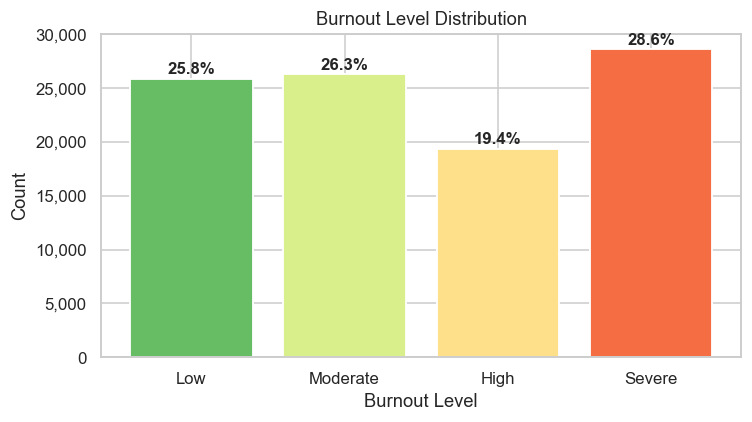

burnout_level
Low         25807
Moderate    26255
High        19362
Severe      28576


In [6]:
vc  = df[TARGET].value_counts().reindex(['Low', 'Moderate', 'High', 'Severe'])
pct = vc / vc.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(vc.index, vc.values,
              color=sns.color_palette('RdYlGn_r', 4), edgecolor='white', linewidth=1.2)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 180,
            f'{p:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set(title='Burnout Level Distribution', xlabel='Burnout Level', ylabel='Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout(); plt.show()
print(vc.to_string())

### 5.2  Numeric feature distributions

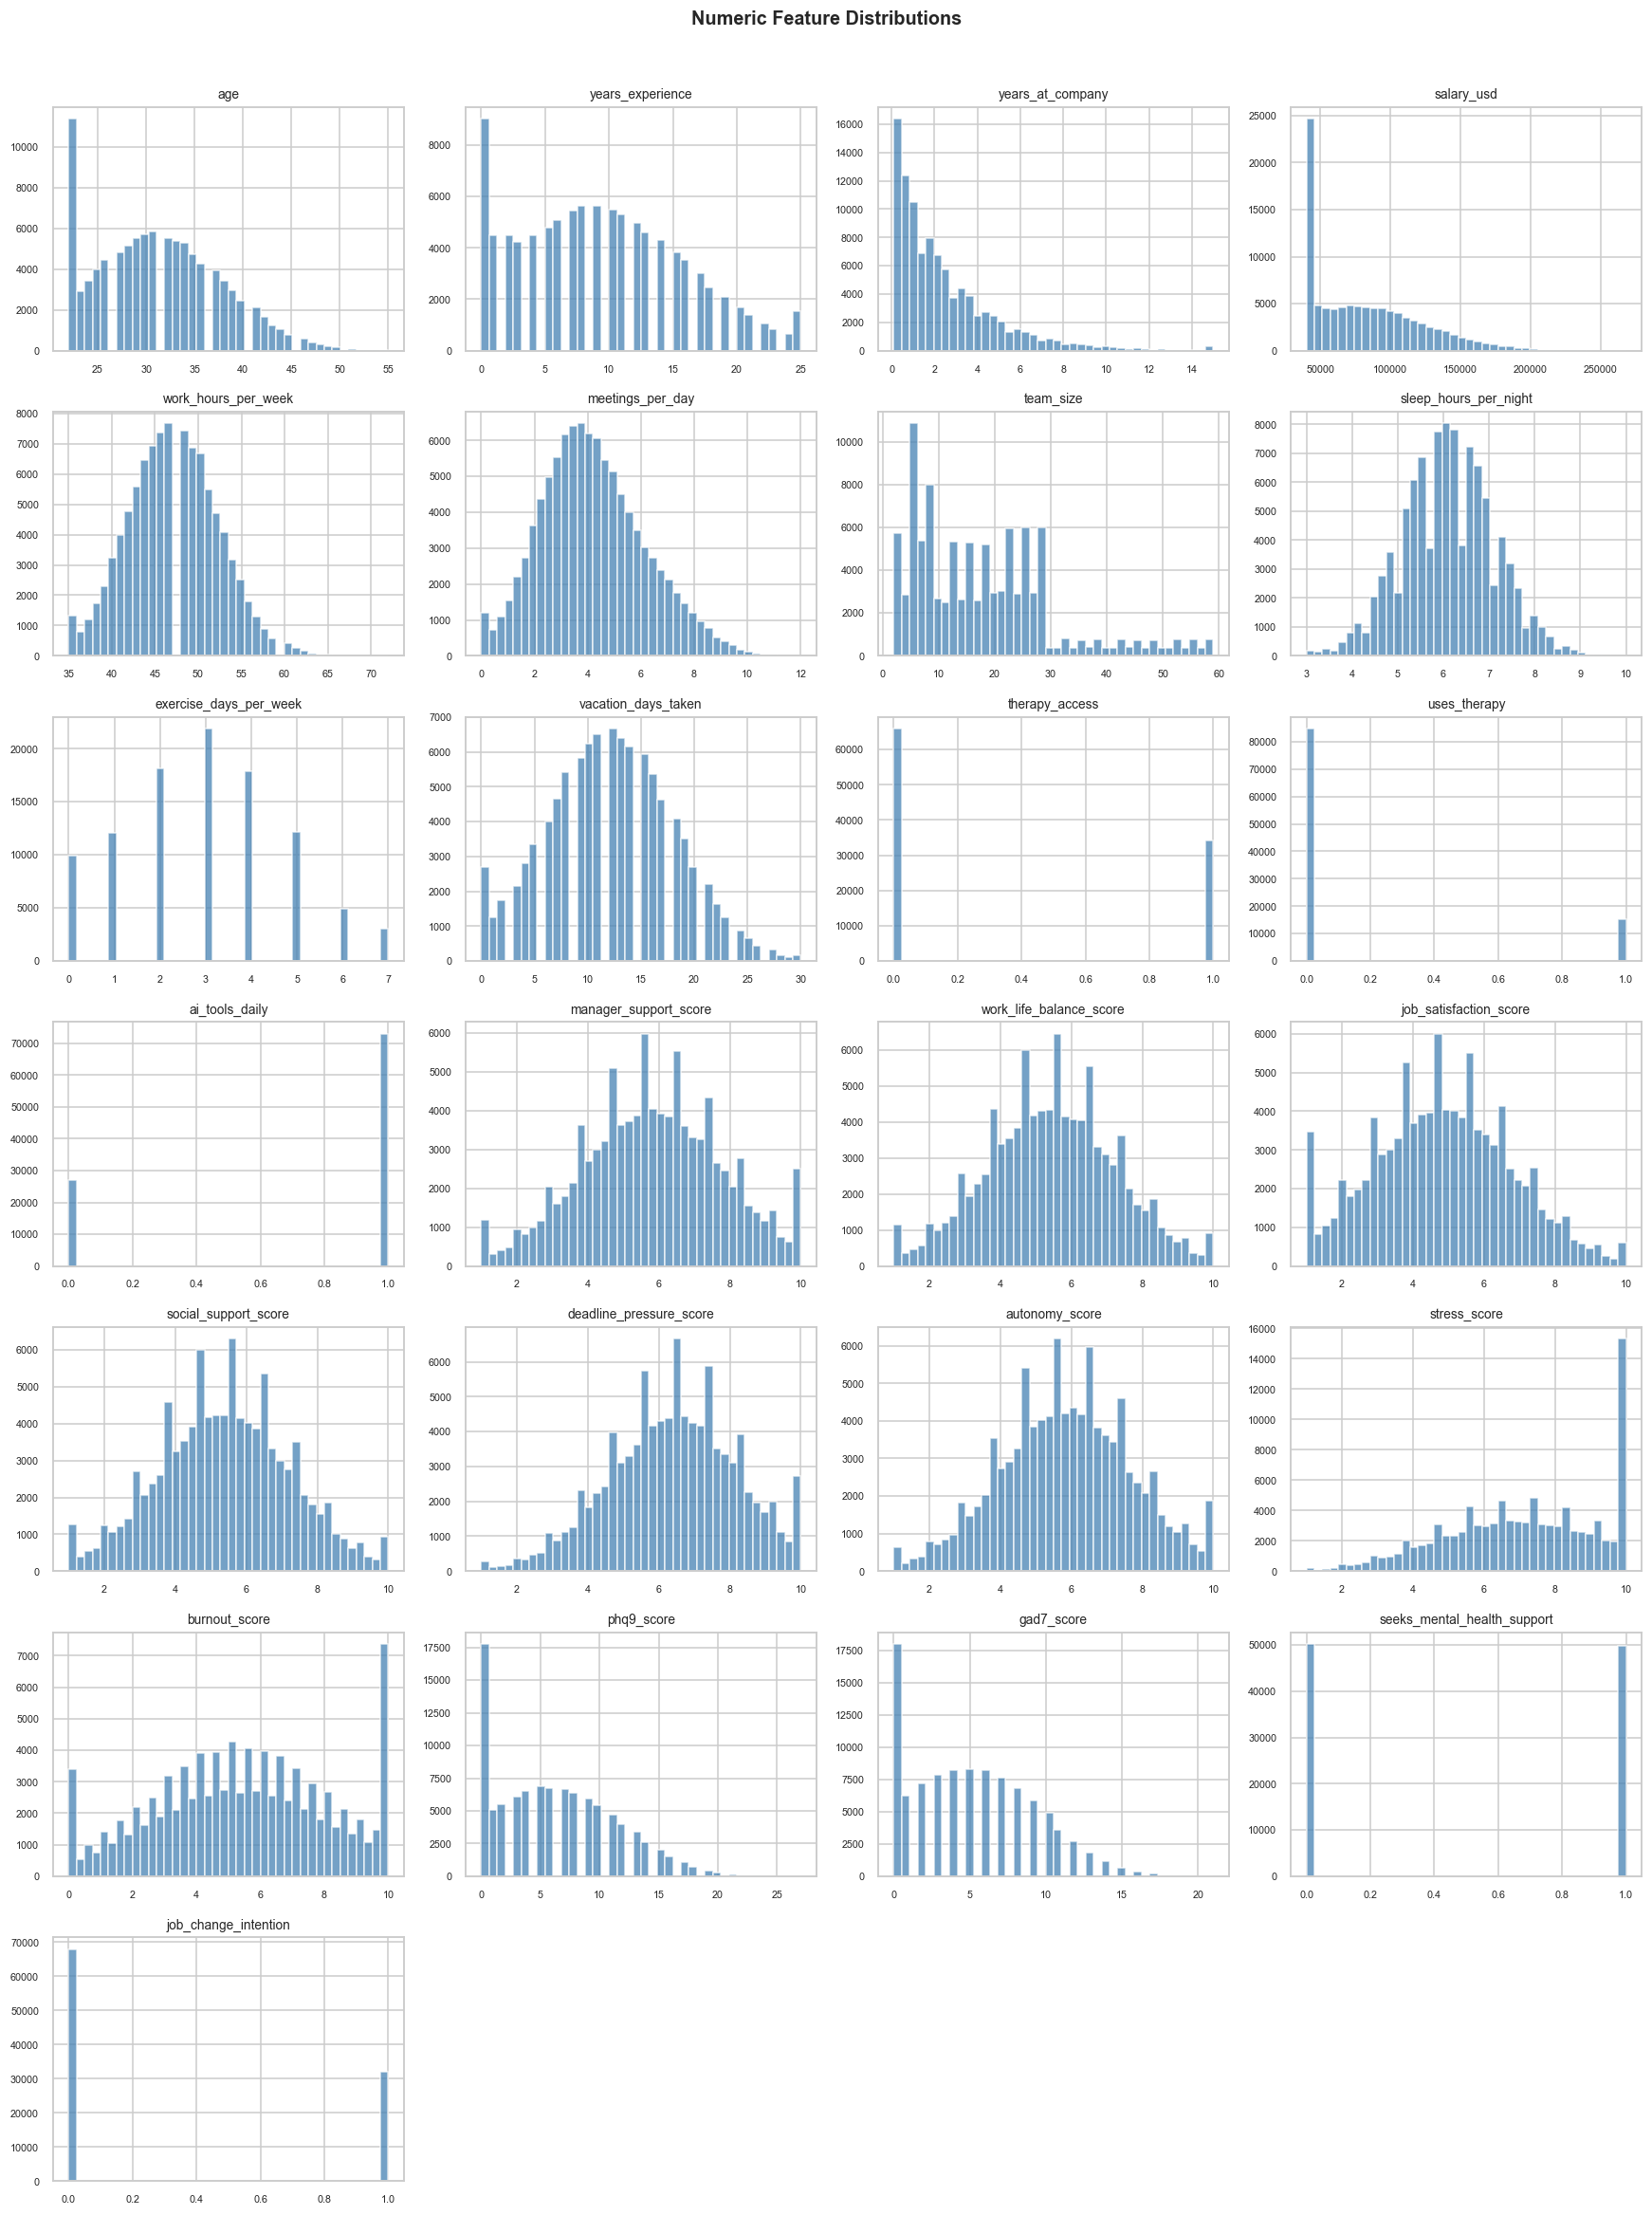

In [7]:
num_cols_plot = df.select_dtypes(include=np.number).columns.drop(ID_COLS).tolist()
n_cols = 4
n_rows = -(-len(num_cols_plot) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols_plot):
    axes[i].hist(df[col], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.3  Correlation heatmap (key features)

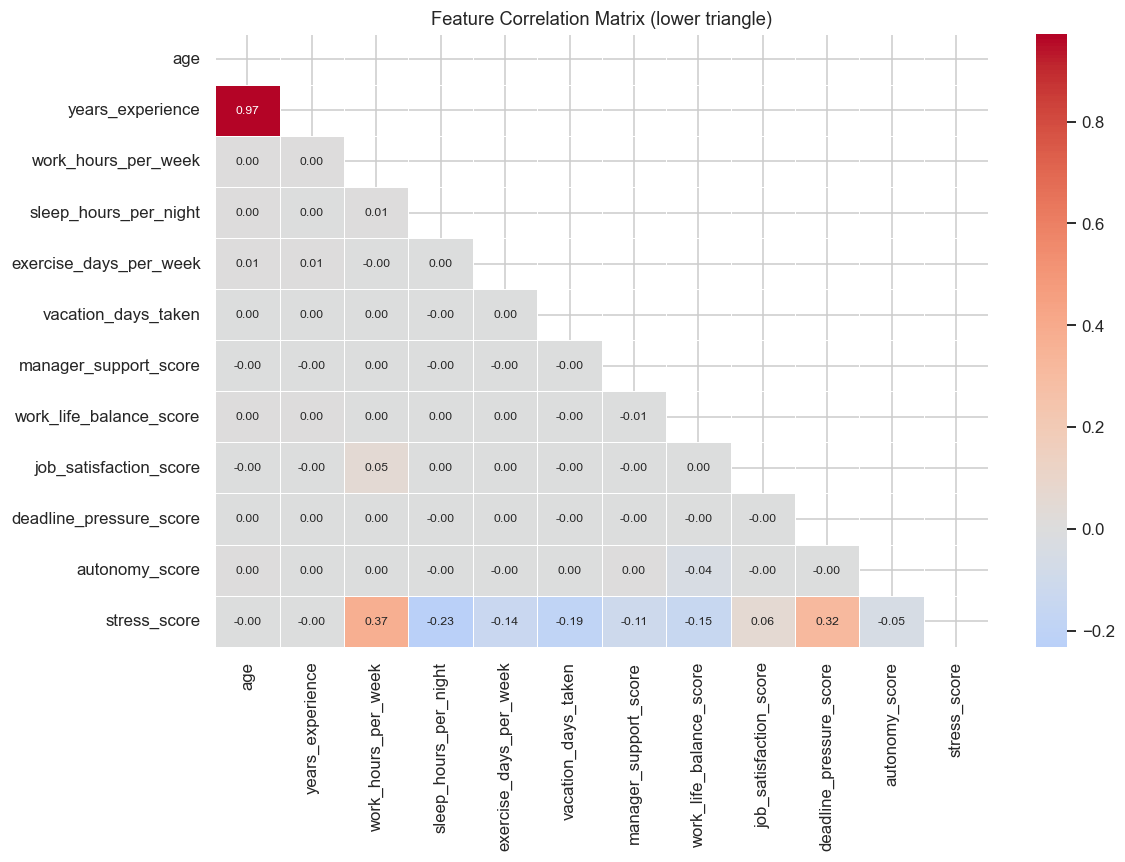

In [8]:
key_cols = ['age', 'years_experience', 'work_hours_per_week', 'sleep_hours_per_night',
            'exercise_days_per_week', 'vacation_days_taken', 'manager_support_score',
            'work_life_balance_score', 'job_satisfaction_score', 'deadline_pressure_score',
            'autonomy_score', 'stress_score']

corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=12)
plt.tight_layout(); plt.show()

### 5.4  Categorical feature distributions

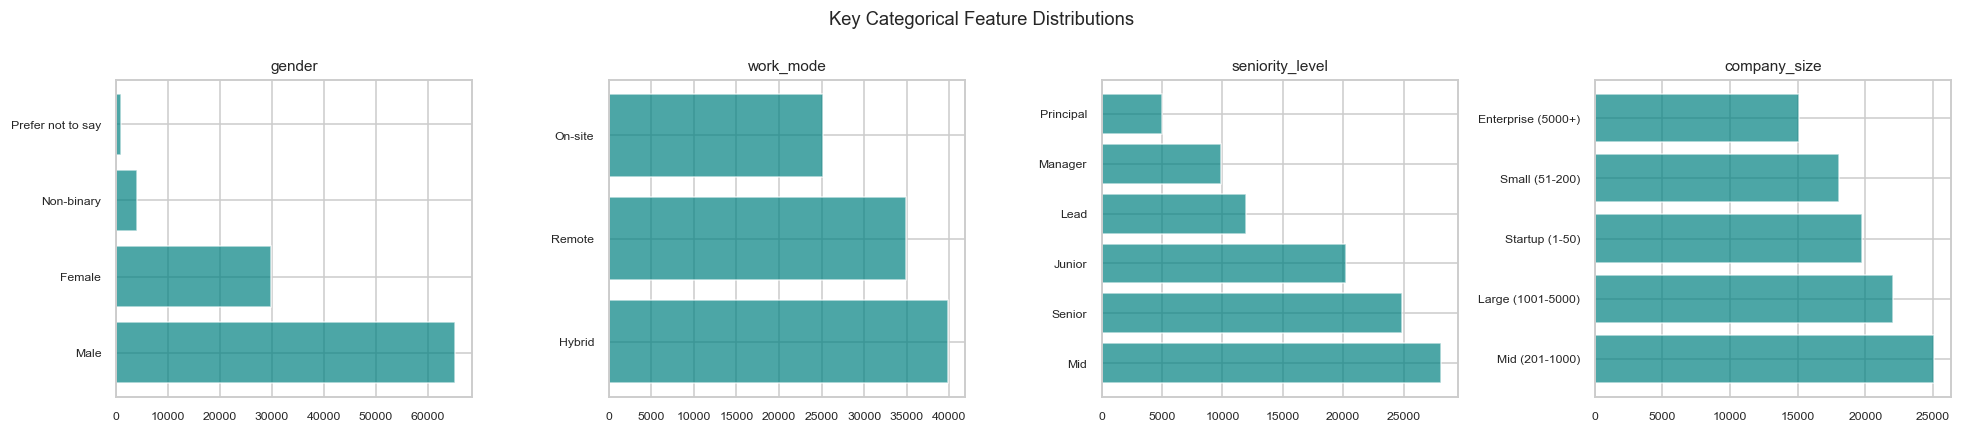

In [9]:
cat_cols_plot = ['gender', 'work_mode', 'seniority_level', 'company_size']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols_plot):
    vc2 = df[col].value_counts()
    ax.barh(vc2.index, vc2.values, color='teal', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle('Key Categorical Feature Distributions', fontsize=12)
plt.tight_layout(); plt.show()

## 6 · Outlier Detection (IQR Multi-Column Rule)

A row is dropped only if it is an IQR outlier in **≥ 2** bounded numeric columns,  
avoiding the loss of rows that are merely unusual in one dimension.  
The per-column bounds are saved in `feature_meta.json` so the dashboard can warn  
when a prediction-form input falls outside the trained range.

In [10]:
bounds   = {}
flag_mat = np.zeros((len(df), len(IQR_COLS)), dtype=bool)

for j, col in enumerate(IQR_COLS):
    q1, q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr_val = q3 - q1
    lo, hi  = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val
    bounds[col] = {'low': float(lo), 'high': float(hi),
                   'q1': float(q1), 'q3': float(q3)}
    flag_mat[:, j] = (df[col] < lo) | (df[col] > hi)

drop_mask = flag_mat.sum(axis=1) >= 2
df        = df.loc[~drop_mask].reset_index(drop=True)
print(f'Dropped {int(drop_mask.sum()):,} rows ({drop_mask.mean():.2%}) -> {len(df):,} remaining')

Dropped 408 rows (0.41%) -> 99,592 remaining


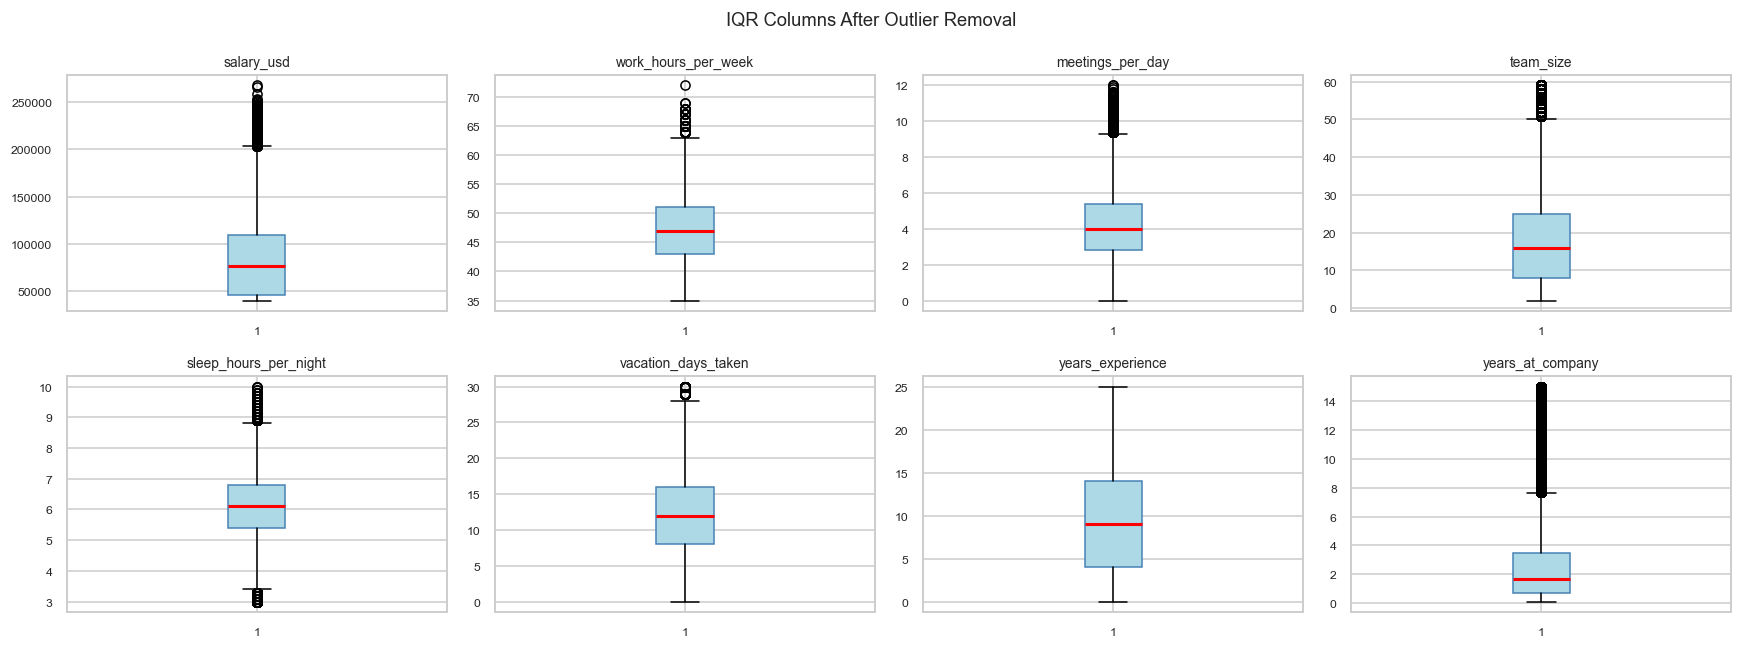

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for ax, col in zip(axes, IQR_COLS):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)
plt.suptitle('IQR Columns After Outlier Removal', fontsize=12)
plt.tight_layout(); plt.show()

## 7 · Feature Engineering

All 19 derived features are **row-wise transforms** (no statistics learned from data),  
so they can be applied before the split without any risk of leakage.

| Group | Features |
| ----- | -------- |
| Ordinal encoding | `seniority_ord`, `company_size_ord` |
| Composite interactions | `work_recovery_ratio`, `pressure_vs_support`, `resilience_index`, `tenure_experience_ratio`, `salary_per_experience`, `meetings_burden` |
| Log transforms | `log_salary`, `log_team_size` |
| Binary flags | `overworked`, `sleep_deprived`, `no_vacation`, `high_meetings`, `no_exercise` |
| Polynomial cross-products | `stress_x_hours`, `stress_x_sleep_inv`, `pressure_x_imbalance`, `stress_x_no_support` |

In [12]:
raw_df = df.copy()   # keep pre-engineering copy for feature_meta ranges
eng_df = engineer_features(df)

derived = [c for c in eng_df.columns if c not in df.columns]
print(f'Added {len(derived)} engineered features:')
for f in derived:
    print(f'  {f}')

Added 19 engineered features:
  seniority_ord
  company_size_ord
  work_recovery_ratio
  pressure_vs_support
  resilience_index
  tenure_experience_ratio
  salary_per_experience
  meetings_burden
  log_salary
  log_team_size
  overworked
  sleep_deprived
  no_vacation
  high_meetings
  no_exercise
  stress_x_hours
  stress_x_sleep_inv
  pressure_x_imbalance
  stress_x_no_support


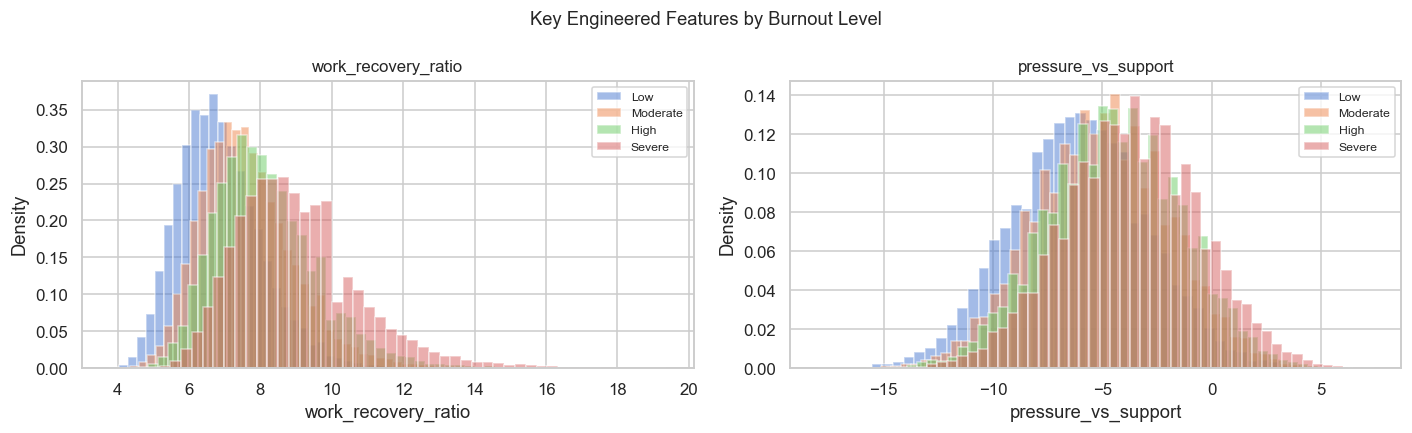

In [13]:
# Visualise the two strongest engineered features split by burnout_level.
# Use a temporary copy so eng_df is never mutated -- the drop(columns=...)
# in the next cell expects burnout_level to still be present in eng_df.
plot_df = eng_df.copy()
plot_df['burnout_level'] = df[TARGET]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['work_recovery_ratio', 'pressure_vs_support']):
    for level in ['Low', 'Moderate', 'High', 'Severe']:
        vals = plot_df.loc[plot_df['burnout_level'] == level, col]
        ax.hist(vals, bins=50, alpha=0.5, label=level, density=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Key Engineered Features by Burnout Level', fontsize=12)
plt.tight_layout(); plt.show()
del plot_df  # keep namespace clean

## 8 · Preprocessing & Train/Test Split

- `seniority_level` and `company_size` are dropped from raw columns — they are  
  already represented as ordinal integers `seniority_ord` / `company_size_ord`.
- Low-cardinality categoricals (`gender`, `work_mode`) → **OneHotEncoder**
- High-cardinality categoricals (`country`, `job_role`, `industry`) → **TargetEncoder**  
  (`target_type='multiclass'`): encodes each category as a 4-dim probability vector —  
  denser signal than 30+ dummy columns; handles unseen values via the prior.

In [14]:
drop_all   = LEAKAGE_COLS + ID_COLS + [TARGET] + RAW_CATEGORICAL_COLS
feature_df = eng_df.drop(columns=drop_all)
feature_df = pd.concat([feature_df, eng_df[MODEL_CATEGORICAL_COLS]], axis=1)

raw_numeric_cols   = [c for c in raw_df.drop(columns=LEAKAGE_COLS + ID_COLS + [TARGET]).columns
                      if c not in RAW_CATEGORICAL_COLS]
model_numeric_cols = [c for c in feature_df.columns if c not in MODEL_CATEGORICAL_COLS]

print(f'Feature matrix  : {feature_df.shape}')
print(f'  Numeric cols  : {len(model_numeric_cols)}')
print(f'  Categoric cols: {len(MODEL_CATEGORICAL_COLS)}')

le = LabelEncoder()
y  = le.fit_transform(df[TARGET])
print(f'\nClass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Feature matrix  : (99592, 44)
  Numeric cols  : 39
  Categoric cols: 5

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}
Train: (79673, 44)  |  Test: (19919, 44)


### Preprocessor definition

In [15]:
def build_preprocessor(numeric_cols, categorical_cols):
    """Three-branch ColumnTransformer: numeric / OHE (low-card) / TargetEncoder (high-card)."""
    numeric_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ])
    ohe_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    target_enc_pipe = Pipeline([
        ('impute',     SimpleImputer(strategy='most_frequent')),
        ('target_enc', TargetEncoder(target_type='multiclass',
                                     smooth='auto', random_state=RANDOM_STATE)),
    ])
    low_card  = [c for c in categorical_cols if c in LOW_CARD_CATS]
    high_card = [c for c in categorical_cols if c in HIGH_CARD_CATS]
    transformers = [('num', numeric_pipe, numeric_cols)]
    if low_card:  transformers.append(('ohe',    ohe_pipe,        low_card))
    if high_card: transformers.append(('target', target_enc_pipe, high_card))
    return ColumnTransformer(transformers)

print('build_preprocessor() defined ✓')

build_preprocessor() defined ✓


### Soft-Voting Ensemble

In [16]:
class SoftVotingEnsemble:
    """Averages predict_proba from multiple fitted pipelines.
    Saved as model.joblib so app.py calls .predict_proba() uniformly.
    """
    def __init__(self, pipelines):
        self.pipelines = pipelines
    def predict_proba(self, X):
        return np.mean([p.predict_proba(X) for p in self.pipelines], axis=0)
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

print('SoftVotingEnsemble defined ✓')

SoftVotingEnsemble defined ✓


## 9 · Model Training & Comparison

| Model | Key settings |
| ----- | ------------ |
| LogisticRegression | `C=3.0`, `class_weight='balanced'` |
| HistGradientBoosting | `max_iter=400`, `lr=0.05`, `max_depth=6`, `class_weight='balanced'` |
| XGBoost | `n_estimators=400`, `lr=0.05`, `max_depth=6`, `sample_weight` externally |
| Ensemble | Soft-vote (average probabilities) of all three |

In [17]:
sample_weights = compute_sample_weight('balanced', y_train)

candidates = {
    'LogisticRegression': LogisticRegression(
        max_iter=2000, n_jobs=-1, C=3.0, class_weight='balanced'
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=6,
        min_samples_leaf=30, class_weight='balanced', random_state=RANDOM_STATE,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss',
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
}

leaderboard, fitted_pipes = {}, {}
best_name, best_obj, best_f1 = None, None, -1.0

for name, clf in candidates.items():
    pre  = build_preprocessor(model_numeric_cols, MODEL_CATEGORICAL_COLS)
    pipe = Pipeline([('pre', pre), ('clf', clf)])
    t0   = time.time()
    if name == 'XGBoost':
        pipe.fit(X_train, y_train, clf__sample_weight=sample_weights)
    else:
        pipe.fit(X_train, y_train)
    preds   = pipe.predict(X_test)
    f1_mac  = f1_score(y_test, preds, average='macro')
    acc     = accuracy_score(y_test, preds)
    elapsed = time.time() - t0
    leaderboard[name]  = {'macro_f1': float(f1_mac), 'accuracy': float(acc), 'fit_seconds': float(elapsed)}
    fitted_pipes[name] = pipe
    print(f'  {name:<24s}  acc={acc:.3f}  macro-F1={f1_mac:.3f}  ({elapsed:.1f}s)')
    if f1_mac > best_f1:
        best_f1, best_name, best_obj = f1_mac, name, pipe

# Soft-voting ensemble
t0       = time.time()
ensemble = SoftVotingEnsemble(list(fitted_pipes.values()))
ens_pred = ensemble.predict(X_test)
ens_f1   = f1_score(y_test, ens_pred, average='macro')
ens_acc  = accuracy_score(y_test, ens_pred)
leaderboard['Ensemble(LR+HGB+XGB)'] = {
    'macro_f1': float(ens_f1), 'accuracy': float(ens_acc), 'fit_seconds': float(time.time() - t0)}
print(f"  {'Ensemble(LR+HGB+XGB)':<24s}  acc={ens_acc:.3f}  macro-F1={ens_f1:.3f}")
if ens_f1 > best_f1:
    best_f1, best_name, best_obj = ens_f1, 'Ensemble(LR+HGB+XGB)', ensemble
print(f'\nWinner -> {best_name}  (macro-F1 = {best_f1:.3f})')

  LogisticRegression        acc=0.704  macro-F1=0.693  (4.6s)
  HistGradientBoosting      acc=0.701  macro-F1=0.692  (11.3s)
  XGBoost                   acc=0.702  macro-F1=0.693  (12.6s)
  Ensemble(LR+HGB+XGB)      acc=0.706  macro-F1=0.696

Winner -> Ensemble(LR+HGB+XGB)  (macro-F1 = 0.696)


### Leaderboard chart

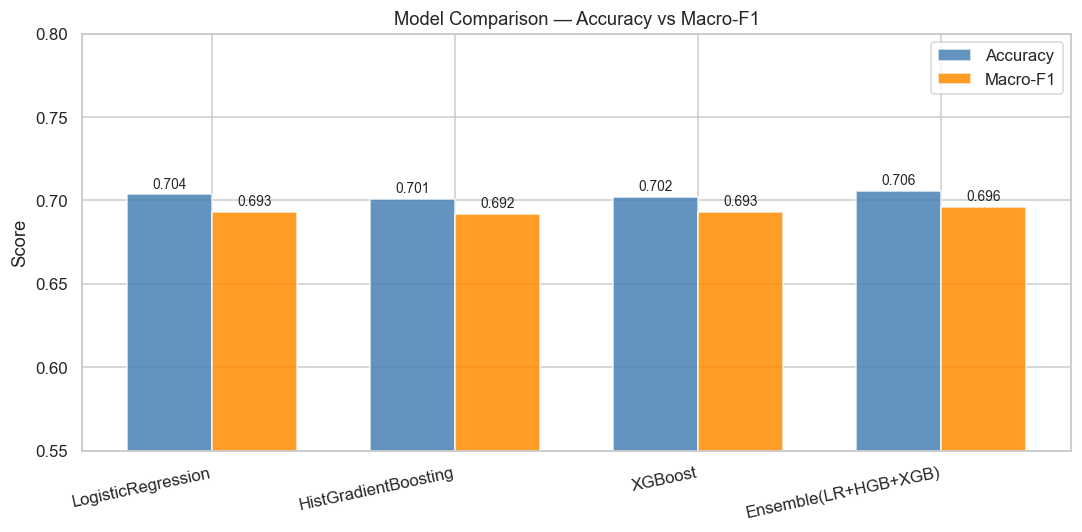

In [18]:
names  = list(leaderboard.keys())
f1s    = [leaderboard[n]['macro_f1'] for n in names]
accs   = [leaderboard[n]['accuracy']  for n in names]

x, width = np.arange(len(names)), 0.35
fig, ax  = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, accs, width, label='Accuracy',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, f1s,  width, label='Macro-F1', color='darkorange', alpha=0.85)
ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=12, ha='right')
ax.set_ylim(0.55, 0.80)
ax.set(title='Model Comparison — Accuracy vs Macro-F1', ylabel='Score')
ax.legend()
plt.tight_layout(); plt.show()

## 10 · Evaluate the Winning Model

### 10.1  Classification report

In [19]:
preds       = best_obj.predict(X_test)
acc         = accuracy_score(y_test, preds)
macro_f1    = f1_score(y_test, preds, average='macro')
weighted_f1 = f1_score(y_test, preds, average='weighted')

print(f'Winner       : {best_name}')
print(f'Accuracy     : {acc:.4f}')
print(f'Macro F1     : {macro_f1:.4f}')
print(f'Weighted F1  : {weighted_f1:.4f}')
print()
report_dict = classification_report(
    y_test, preds, target_names=le.classes_.tolist(), output_dict=True, zero_division=0
)
print(classification_report(y_test, preds, target_names=le.classes_.tolist(), zero_division=0))

Winner       : Ensemble(LR+HGB+XGB)
Accuracy     : 0.7058
Macro F1     : 0.6963
Weighted F1  : 0.7102

              precision    recall  f1-score   support

        High       0.49      0.58      0.53      3861
         Low       0.83      0.81      0.82      5143
    Moderate       0.62      0.59      0.60      5235
      Severe       0.86      0.80      0.83      5680

    accuracy                           0.71     19919
   macro avg       0.70      0.70      0.70     19919
weighted avg       0.72      0.71      0.71     19919



### 10.2  Confusion matrix

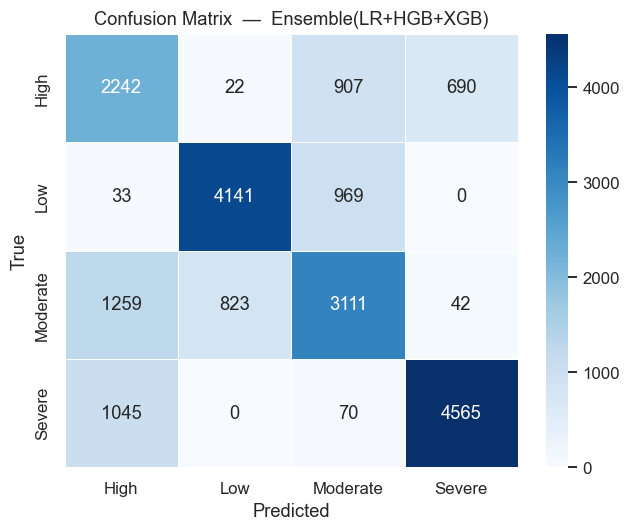

In [20]:
cm     = confusion_matrix(y_test, preds)
labels = le.classes_.tolist()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set(title=f'Confusion Matrix  —  {best_name}',
       xlabel='Predicted', ylabel='True')
plt.tight_layout(); plt.show()

### 10.3  Per-class F1 breakdown

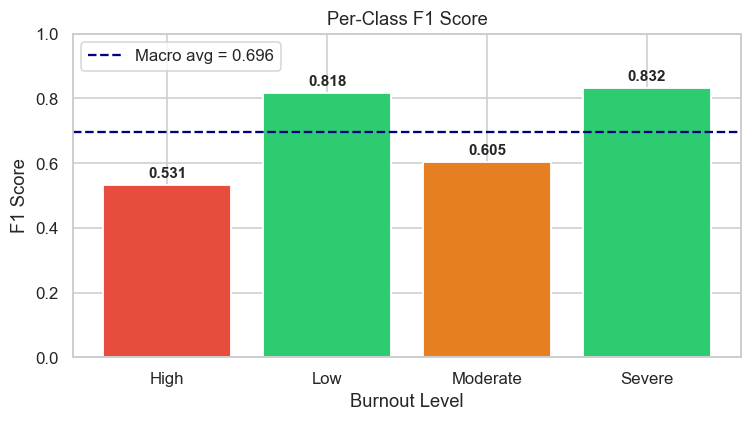

In [21]:
class_f1s = [report_dict[c]['f1-score'] for c in labels]
colors    = ['#2ecc71' if f >= 0.75 else '#e67e22' if f >= 0.55 else '#e74c3c'
             for f in class_f1s]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, class_f1s, color=colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')
ax.axhline(macro_f1, ls='--', color='navy', lw=1.5,
           label=f'Macro avg = {macro_f1:.3f}')
ax.set(title='Per-Class F1 Score', xlabel='Burnout Level',
       ylabel='F1 Score', ylim=(0, 1.0))
ax.legend()
plt.tight_layout(); plt.show()

### 10.4  Permutation importance (top 15)

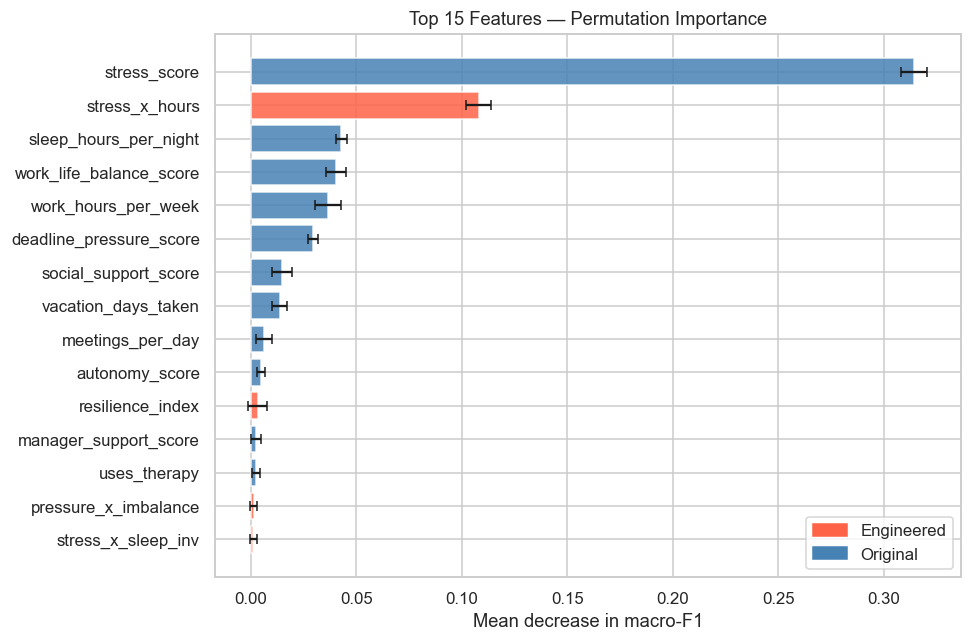

                feature  importance      std
           stress_score    0.314449 0.006196
         stress_x_hours    0.107942 0.005777
  sleep_hours_per_night    0.042915 0.002710
work_life_balance_score    0.040501 0.004872
    work_hours_per_week    0.036674 0.006164
deadline_pressure_score    0.029557 0.002241
   social_support_score    0.014834 0.004751
    vacation_days_taken    0.013709 0.003678
       meetings_per_day    0.006460 0.003754
         autonomy_score    0.004746 0.001972
       resilience_index    0.003252 0.004321
  manager_support_score    0.002507 0.002517
           uses_therapy    0.002455 0.001973
   pressure_x_imbalance    0.001419 0.001538
     stress_x_sleep_inv    0.001232 0.001792


In [22]:
perm_model  = best_obj.pipelines[0] if isinstance(best_obj, SoftVotingEnsemble) else best_obj
sample_size = min(3000, len(X_test))
idx         = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=sample_size, replace=False)

perm   = permutation_importance(
    perm_model, X_test.iloc[idx], y_test[idx],
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=1,  scoring='f1_macro'
)
imp_df = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False).head(15)

ENGINEERED = {'stress_x_hours', 'stress_x_sleep_inv', 'pressure_x_imbalance',
              'stress_x_no_support', 'work_recovery_ratio', 'resilience_index',
              'pressure_vs_support', 'seniority_ord', 'company_size_ord',
              'log_salary', 'log_team_size', 'overworked', 'sleep_deprived',
              'no_vacation', 'high_meetings', 'no_exercise', 'meetings_burden',
              'tenure_experience_ratio', 'salary_per_experience'}
colors = ['tomato' if f in ENGINEERED else 'steelblue' for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors[::-1], xerr=imp_df['std'][::-1], capsize=3, alpha=0.85)
ax.set(title='Top 15 Features — Permutation Importance',
       xlabel='Mean decrease in macro-F1')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tomato',    label='Engineered'),
                   Patch(color='steelblue', label='Original')], loc='lower right')
plt.tight_layout(); plt.show()
print(imp_df.to_string(index=False))

## 11 · Save Artefacts

In [23]:
# Convert numpy floats to Python floats so json.dumps() can serialise them
importance_list = [
    {'feature': r['feature'], 'importance': float(r['importance']), 'std': float(r['std'])}
    for r in imp_df.to_dict('records')
]

metrics = {
    'winning_model':          best_name,
    'accuracy':               float(acc),
    'macro_f1':               float(macro_f1),
    'weighted_f1':            float(weighted_f1),
    'classification_report':  report_dict,
    'confusion_matrix':       cm.tolist(),
    'class_labels':           labels,
    'permutation_importance': importance_list,
    'leaderboard':            leaderboard,
}

feature_meta = {
    'numeric':        {},
    'categorical':    {},
    'derived_numeric':{},
    'iqr_bounds':     bounds,
    'feature_order':  model_numeric_cols + MODEL_CATEGORICAL_COLS,
}
for col in raw_numeric_cols:
    s = raw_df[col]
    feature_meta['numeric'][col] = {
        'min': float(s.min()), 'max': float(s.max()),
        'median': float(s.median()),
        'is_integer': bool(pd.api.types.is_integer_dtype(s)),
    }
for col in RAW_CATEGORICAL_COLS:
    feature_meta['categorical'][col] = sorted(raw_df[col].dropna().unique().tolist())
derived_cols = [c for c in model_numeric_cols if c not in raw_numeric_cols]
for col in derived_cols:
    s = eng_df[col]
    feature_meta['derived_numeric'][col] = {
        'min': float(s.min()), 'max': float(s.max()), 'median': float(s.median()),
    }

joblib.dump(best_obj, ART_DIR / 'model.joblib')
joblib.dump(le,       ART_DIR / 'label_encoder.joblib')
(ART_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
(ART_DIR / 'feature_meta.json').write_text(json.dumps(feature_meta, indent=2))

print('Saved artefacts:')
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:<30s} {p.stat().st_size / 1024:>6.0f} KB')

Saved artefacts:
  feature_meta.json                   8 KB
  label_encoder.joblib                0 KB
  metrics.json                        4 KB
  model.joblib                    10100 KB
  univariate.json                    10 KB


---
## ✅ Done

Artefacts ready for the Streamlit dashboard:
```
artifacts/
  model.joblib           <- trained pipeline / ensemble
  label_encoder.joblib   <- maps 0-3 -> Low / Moderate / High / Severe
  metrics.json           <- accuracy, F1, confusion matrix, feature importance
  feature_meta.json      <- slider ranges + dropdown options for the predict form
  univariate.json        <- pre-computed stats for the EDA page
```

Launch the dashboard:
```bash
streamlit run "D:\Users\Hady\Documents\Epsilon Final Project\app.py"
```